## Steered MD stability analysis

This notebook evaluates whether the system has stable RMSD and Boresch orientation during the steered MD simulation.

In [ ]:
import numpy as np
import MDAnalysis as mda
from MDAnalysis.analysis import rms, align
import matplotlib.pyplot as plt
from MDAnalysis.analysis.distances import dist
from tqdm import tqdm
import yaml

In [2]:
def getDistance(idx1, idx2, u):
    """
    Get the distance between two atoms in a universe.

    Parameters
    ----------
    idx1 : int
        Index of the first atom
    idx2 : int
        Index of the second atom
    u : MDAnalysis.Universe
        The MDA universe containing the atoms and
        trajectory.

    Returns
    -------
    distance : float
        The distance between the two atoms in Angstroms.
    """
    distance = dist(
        mda.AtomGroup([u.atoms[idx1]]),
        mda.AtomGroup([u.atoms[idx2]]),
        box=u.dimensions,
    )[2][0]
    return distance

def closest_residue_to_point(atoms, point):
    """Find the closest residue in a selection of atoms to a given point"""
    residues = atoms.residues
    distances = np.array([np.linalg.norm(res.atoms.center_of_mass() - point) for res in residues])

    # Find the index of the smallest distance
    closest_residue_index = np.argmin(distances)

    # Return the closest residue
    return residues[closest_residue_index], distances[closest_residue_index]

def obtain_CA_idx(u, res_idx):
    """Function to obtain the index of the alpha carbon for a given residue index"""
    
    selection_str = f"resid {res_idx} and name CA"
    
    selected_CA = u.select_atoms(selection_str)

    if len(selected_CA.indices) == 0 or selected_CA.indices[0] == None:
        print(f'CA not found for the residue {res_idx}...')

        return np.nan
    
    elif len(selected_CA.indices) > 1:
        print('Multiple CAs found, uh oh...')

    else:  
        return selected_CA.indices[0]
    
def obtain_angle(pos1, pos2, pos3):

    return mda.lib.distances.calc_angles(pos1, pos2, pos3)

def obtain_dihedral(pos1, pos2, pos3, pos4):
    
    return mda.lib.distances.calc_dihedrals(pos1, pos2, pos3, pos4)
  
def obtain_RMSD(u, res_range):

    protein = u.select_atoms("protein")

    ref = protein
    R_u =rms.RMSD(protein, ref, select=f'backbone and resid {res_range[0]}-{res_range[1]}')
    R_u.run()

    rmsd_u = R_u.rmsd.T #take transpose
    time = rmsd_u[1]/1000
    rmsd= rmsd_u[2]

    return time, rmsd

### Plotting RMSD

/home/btan/miniconda3/envs/openbiosim/lib/python3.11/site-packages/MDAnalysis/topology/TOPParser.py:342: UserWarning: Unknown ATOMIC_NUMBER value found for some atoms, these have been given an empty element record. If needed these can be guessed using universe.guess_TopologyAttrs(to_guess=['elements']).
  warnings.warn(msg)
/home/btan/miniconda3/envs/openbiosim/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
/home/btan/miniconda3/envs/openbiosim/lib/python3.11/site-packages/MDAnalysis/analysis/rms.py:824: DeprecationWarning: The `rmsd` attribute was deprecated in MDAnalysis 2.0.0 and will b

Text(0.5, 0, 'Time')

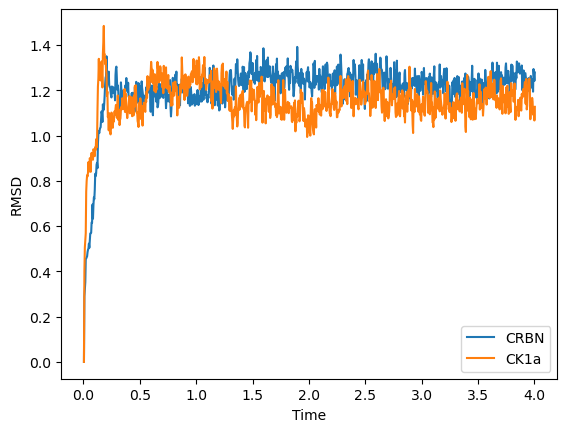

In [3]:
u = mda.Universe('../../../equilibrated_structures/complex_eq.prmtop', 'sep_traj.dcd')
time_rec, rmsd_rec = obtain_RMSD(u, res_range=[0,312])
time_lig, rmsd_lig = obtain_RMSD(u, res_range=[314, 606])

plt.plot(time_rec, rmsd_rec, label='CRBN')
plt.plot(time_lig, rmsd_lig, label='CK1a')
plt.legend()
plt.ylabel('RMSD')
plt.xlabel('Time')

### Plotting Boresch DOFs

In [ ]:
def obtain_Boresch_dof(u, dof):

    with open('../../../US_config.yaml', 'r') as file:
        US_data = yaml.safe_load(file)

    rec_interface_res = US_data['Receptor interface residues']
    lig_interface_res =  US_data['Ligand interface residues']

    # Define anchor points (1-indexing)
    res_b = US_data['Boresch anchor points']['res_b']
    res_c = US_data['Boresch anchor points']['res_c']
    res_B = US_data['Boresch anchor points']['res_B']
    res_C = US_data['Boresch anchor points']['res_C']

    glue_indices = [FIXME] # heavy atom indices restrained by RMSD restraints

    group_a_selection = [obtain_CA_idx(u, res) for res in rec_interface_res] + glue_indices

    group_a = u.atoms[group_a_selection]
    group_b = u.atoms[[obtain_CA_idx(u, res_b)]]
    group_c = u.atoms[[obtain_CA_idx(u, res_c)]]
    group_A = u.atoms[[obtain_CA_idx(u, res) for res in lig_interface_res]]
    group_B = u.atoms[[obtain_CA_idx(u, res_B)]]
    group_C = u.atoms[[obtain_CA_idx(u, res_C)]]

    pos_a = group_a.center_of_mass()
    pos_b = group_b.center_of_mass()
    pos_c = group_c.center_of_mass()
    
    pos_A = group_A.center_of_mass()
    pos_B = group_B.center_of_mass()
    pos_C = group_C.center_of_mass()

    dof_indices = {
        'thetaA' : [pos_b, pos_a, pos_A],
        'thetaB' : [pos_a, pos_A, pos_B],
        'phiA' : [pos_c, pos_b, pos_a, pos_A],
        'phiB': [pos_b, pos_a, pos_A, pos_B],
        'phiC': [pos_a, pos_A, pos_B, pos_C]
    }

    indices = dof_indices[dof]

    if len(indices) == 3:
        return obtain_angle(indices[0], indices[1], indices[2])

    else:
        return obtain_dihedral(indices[0], indices[1], indices[2], indices[3])


In [10]:
with open('../../../US_config.yaml', 'r') as file:
    US_data = yaml.safe_load(file)

eq_vals = {'thetaA' : US_data['Boresch equilibrium values']['theta_A_0'],
           'thetaB' : US_data['Boresch equilibrium values']['theta_B_0'],
           'phiA' : US_data['Boresch equilibrium values']['phi_A_0'],
           'phiB' : US_data['Boresch equilibrium values']['phi_B_0'],
           'phiC' : US_data['Boresch equilibrium values']['phi_C_0']}



In [11]:
u = mda.Universe('../../../equilibrated_structures/complex_eq.prmtop', 'sep_traj.dcd')

dofs = eq_vals.keys()
dof_data = []

for dof in dofs:

    vals = []

    for ts in tqdm(u.trajectory[::10], total=u.trajectory.n_frames/10, desc=f'{dof} analysis'):
        vals.append(obtain_Boresch_dof(u, dof))
    
    dof_data.append(vals)
               

/home/btan/miniconda3/envs/openbiosim/lib/python3.11/site-packages/MDAnalysis/topology/TOPParser.py:342: UserWarning: Unknown ATOMIC_NUMBER value found for some atoms, these have been given an empty element record. If needed these can be guessed using universe.guess_TopologyAttrs(to_guess=['elements']).
  warnings.warn(msg)
/home/btan/miniconda3/envs/openbiosim/lib/python3.11/site-packages/MDAnalysis/coordinates/DCD.py:165: DeprecationWarning: DCDReader currently makes independent timesteps by copying self.ts while other readers update self.ts inplace. This behavior will be changed in 3.0 to be the same as other readers. Read more at https://github.com/MDAnalysis/mdanalysis/issues/3889 to learn if this change in behavior might affect you.
  warnings.warn("DCDReader currently makes independent timesteps"
thetaA analysis: 101it [00:08, 12.09it/s]                           
thetaB analysis: 101it [00:08, 11.75it/s]                           
phiA analysis: 101it [00:08, 11.88it/s]        

In [12]:
dofs = list(dofs)
frames = np.arange(1, len(dof_data[0]) + 1) 

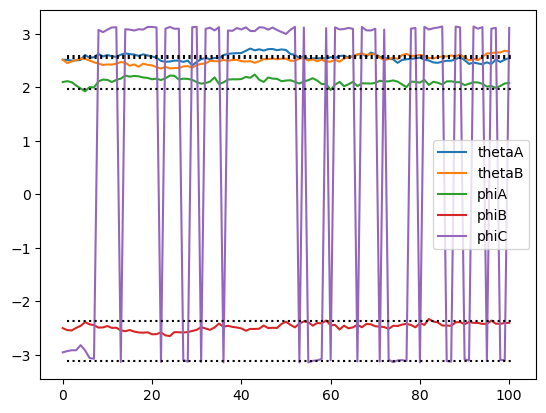

In [13]:
for n in range(len(dofs)):

    plt.plot(dof_data[n], label=dofs[n])

plt.plot(frames, eq_vals['thetaA']*np.ones(len(frames)), c='k', linestyle='dotted')
plt.plot(frames, eq_vals['thetaB']*np.ones(len(frames)), c='k', linestyle='dotted')
plt.plot(frames, eq_vals['phiA']*np.ones(len(frames)), c='k', linestyle='dotted')
plt.plot(frames, eq_vals['phiB']*np.ones(len(frames)), c='k', linestyle='dotted')
plt.plot(frames, eq_vals['phiC']*np.ones(len(frames)), c='k', linestyle='dotted')

plt.legend()